**Modelo ML Prediccion de categorias**

### **Fase 1: Preparación y Fusión de los Datasets**

In [ ]:
import pandas as pd
import numpy as np
import random

# Fijar semilla para reproducibilidad
np.random.seed(42)
random.seed(42)

# Definir las transacciones regionales y específicas de Argentina (Jujuy)
# Estructura: (Descripción, Valor ARS, Categoría)
transacciones_arg = [
    # 1. Educación (Instituto Superior N 5 José Eugenio Tello y UNJU)
    ("Pago de cuota mensual Instituto de Educación Superior N 5 José Eugenio Tello", 12500.0, "educacion"),
    ("Arancel de examen - Universidad Nacional de Jujuy (UNJU)", 5800.0, "educacion"),
    ("Pago matrícula anual de grado UNJU", 24000.0, "educacion"),
    ("Cuota seminario de actualización I.E.S. N 5 José Eugenio Tello", 15000.0, "educacion"),
    ("Derecho de examen extraordinario UNJU Jujuy", 4500.0, "educacion"),

    # 2. Salud / Perfumería (Farmacity)
    ("Compra de medicamentos recetados en Farmacity", 8900.0, "salud"),
    ("Artículos de perfumería y aseo personal en Farmacity sucursal Belgrano", 14300.0, "salud"),
    ("Compra de analgésicos y botiquín en Farmacity Jujuy", 4200.0, "salud"),
    ("Gasto en Farmacity sucursal San Salvador de Jujuy", 11500.0, "salud"),
    ("Compra crema solar y dermocosmética en Farmacity", 19800.0, "salud"),

    # 3. Aplicaciones (Mercado Pago y App Macro)
    ("Transferencia enviada via Mercado Pago", 6500.0, "otros"),
    ("Pago de servicio de gas natural con saldo Mercado Pago", 9500.0, "servicios"),
    ("Pago de factura de telefonía celular por App Macro", 11200.0, "servicios"),
    ("Envío de dinero por Mercado Pago a familiar", 7000.0, "otros"),
    ("Pago con QR Mercado Pago en comercio barrial", 5400.0, "alimentacion"),
    ("Pago de expensas del departamento por App Macro", 42000.0, "vivienda"),
    ("Transferencia realizada mediante App Macro", 18000.0, "otros"),
    ("Recarga de tarjeta SUBE desde Mercado Pago", 3000.0, "transporte"),

    # 4. Localidades: Palpalá y San Salvador de Jujuy (Despensas locales, transporte, comercios)
    ("Pasaje transporte urbano Palpalá - San Salvador de Jujuy", 950.0, "transporte"),
    ("Compra de mercadería en Despensa El Milagro - Palpalá", 11800.0, "alimentacion"),
    ("Gasto en panadería local de San Salvador de Jujuy", 3200.0, "alimentacion"),
    ("Boleto urbano de colectivo - Palpalá Línea 1", 800.0, "transporte"),
    ("Compra de verduras en feria local de Palpalá", 5200.0, "alimentacion"),
    ("Remís desde Terminal de Jujuy hasta Palpalá Centro", 4500.0, "transporte"),
    ("Compra despensa de barrio en San Salvador de Jujuy", 7800.0, "alimentacion"),
    ("Gasto en verdulería y carnicería local en Palpalá", 16500.0, "alimentacion"),
    ("Compra de artículos de almacén en SS de Jujuy", 12400.0, "alimentacion"),
    ("Almuerzo rápido en rotisería local Palpalá", 8200.0, "alimentacion"),

    # 5. Servicios provinciales (luz, agua, internet local)
    ("Pago mensual de luz provincial - EJESA Jujuy", 22500.0, "servicios"),
    ("Factura de agua potable y saneamiento - Agua Potable de Jujuy", 7600.0, "servicios"),
    ("Abono mensual internet local Palpala Conect S.A.", 13800.0, "servicios"),
    ("Pago servicio energía eléctrica EJESA San Salvador", 26000.0, "servicios"),
    ("Servicio de agua corriente y saneamiento Agua Potable Jujuy", 8100.0, "servicios"),
    ("Abono mensual internet provincial Jujuy Banda Ancha", 11500.0, "servicios"),

    # 6. Ocio, streaming, vivienda, otros para completar las 40 filas
    ("Suscripción mensual Netflix Argentina", 6900.0, "streaming"),
    ("Abono mensual Spotify Premium", 2500.0, "streaming"),
    ("Entradas de cine y combos en Cine Alfa San Salvador", 8000.0, "ocio"),
    ("Cena y bebidas en bar de ocio Palpalá Beer", 15000.0, "ocio"),
    ("Suscripción mensual Disney Plus AR", 4900.0, "streaming"),
    ("Alquiler departamento Jujuy Centro", 175000.0, "vivienda")
]

# Mezclar las transacciones para mayor aleatoriedad
random.shuffle(transacciones_arg)

# Extraer listas para las columnas correspondientes
descripciones = [t[0] for t in transacciones_arg]
valores = [t[1] for t in transacciones_arg]
categorias = [t[2] for t in transacciones_arg]

# Generación de fechas dentro del año 2026 distribuidas homogéneamente
fechas = pd.date_range(start="2026-01-01", end="2026-12-31", periods=40).strftime('%Y-%m-%d').tolist()

# Generación de tipos de texto ('natural' o 'cartola')
tipos_texto = np.random.choice(['natural', 'cartola'], size=40)

# Generación de frecuencia de ahorro ('Alta', 'Media', 'Baja')
frecuencias_ahorro = np.random.choice(['Alta', 'Media', 'Baja'], size=40)

# Generación de ingresos mensuales realistas
ingresos_mensuales = np.random.randint(550000, 750000, size=40)

# Generación de nivel de endeudamiento aleatorio
niveles_endeudamiento = np.random.randint(15, 85, size=40)

# Crear el DataFrame de refuerzo con exactamente 40 filas y las columnas requeridas
df_refuerzo = pd.DataFrame({
    'user_id': range(9000, 9040),
    'pais': ['AR'] * 40,
    'moneda': ['ARS'] * 40,
    'ingreso_mensual': ingresos_mensuales,
    'nivel_endeudamiento': niveles_endeudamiento,
    'frecuencia_ahorro': frecuencias_ahorro,
    'descripcion': descripciones,
    'valor': valores,
    'categoria': categorias,
    'fecha': fechas,
    'tipo_texto': tipos_texto
})

Aquí unimos el dataset limpio y el ruidoso, asegurándonos de que los user_id no se superpongan

In [ ]:
# ==========================================
# FASE 1: CARGA Y FUSIÓN DE DATOS
# ==========================================
import pandas as pd
import numpy as np
import random

# Fijar semilla para reproducibilidad
np.random.seed(42)
random.seed(42)

# 1. URLs y Rutas de los 4 datasets
url_limpio = "https://raw.githubusercontent.com/No-Country-simulation/G9-LATAM-Team-53/refs/heads/predataset/Data-science/dataset_10k_usuarios.csv"
url_ruidoso = "https://raw.githubusercontent.com/No-Country-simulation/G9-LATAM-Team-53/refs/heads/predataset/Data-science/dataset_10k_usuarios_2.csv"
url_completo = "https://raw.githubusercontent.com/No-Country-simulation/G9-LATAM-Team-53/refs/heads/predataset/Data-science/dataset_completo_final.csv"
ruta_items = "train_final_con_items.csv" # archivo local

# 2. Lectura de los datasets
df0 = pd.read_csv(url_limpio)
df1 = pd.read_csv(url_ruidoso)
df2 = pd.read_csv(url_completo)

# Leemos el nuevo archivo forzando la limpieza del BOM
df3 = pd.read_csv(ruta_items, encoding='utf-8-sig')
df3.rename(columns={'ï»¿user_id': 'user_id'}, inplace=True)

# 3. Evitar solapamiento de usuarios (La cadena de IDs extendida)
max_id_0 = df0["user_id"].max()
df1["user_id"] = df1["user_id"] + max_id_0

max_id_1 = max(df0["user_id"].max(), df1["user_id"].max())
df2["user_id"] = df2["user_id"] + max_id_1

max_id_2 = max(df1["user_id"].max(), df2["user_id"].max())
df3["user_id"] = df3["user_id"] + max_id_2

max_id_3 = max(df2["user_id"].max(), df3["user_id"].max())
df_refuerzo["user_id"] = df_refuerzo["user_id"] + max_id_3

# 4. Etiquetas de origen para auditoría
df0["origen_dataset"] = "limpio"
df1["origen_dataset"] = "ruidoso"
df2["origen_dataset"] = "completo"
df3["origen_dataset"] = "con_items"
df_refuerzo["origen_dataset"] = "refuerzo"

# 5. Fusión general de las 5 fuentes
df = pd.concat([df0, df1, df2, df3, df_refuerzo], ignore_index=True)

# 6. Manejo de nulos básico
df["descripcion"] = df["descripcion"].fillna("")

print(f"Dataset fusionado con éxito. Total de filas: {df.shape[0]}")
print("\nDistribución de categorías:")
print(df['categoria'].value_counts())

Dataset fusionado con éxito. Total de filas: 114690

Distribución de categorías:
categoria
alimentacion    15249
servicios       13996
transporte      13410
vivienda        13061
salud           12685
ocio            12025
streaming       11585
educacion       11411
otros           11268
Name: count, dtype: int64


In [ ]:
df0.head(1)

,user_id,pais,moneda,ingreso_mensual,nivel_endeudamiento,frecuencia_ahorro,descripcion,valor,categoria,fecha,tipo_texto,origen_dataset
0,1,AR,ARS,267621,19,Baja,deb aut gas nea pos,83525,servicios,2026-01-27,cartola,limpio


In [ ]:
df1.head(1)

,user_id,pais,moneda,ingreso_mensual,nivel_endeudamiento,frecuencia_ahorro,descripcion,valor,categoria,fecha,tipo_texto,origen_dataset
0,81,AR,ARS,201958,56,Alta,compra en optica pförtner,833.0,salud,2026-06-23,natural,ruidoso


In [ ]:
df2.head(1)

,user_id,pais,moneda,ingreso_mensual,nivel_endeudamiento,frecuencia_ahorro,descripcion,valor,categoria,fecha,tipo_texto,comercio,perfil_financiero,probabilidad_perfil,recomendaciones,gasto_total_mes,ratio_gasto_ingreso,origen_dataset
0,339,CL,CLP,1343894,42,Alta,VIAJE EN PEAJE MELIPILLA CONCEPCION,1955,transporte,2026-10-25,natural,Peaje Melipilla,en_observacion,0.6,"[""Revisar suscripciones activas de streaming"",...",9347419,6.955,completo


In [ ]:
print(df0.columns)
print(df1.columns)
print(df2.columns)

Index(['user_id', 'pais', 'moneda', 'ingreso_mensual', 'nivel_endeudamiento',
       'frecuencia_ahorro', 'descripcion', 'valor', 'categoria', 'fecha',
       'tipo_texto', 'origen_dataset'],
      dtype='object')
Index(['user_id', 'pais', 'moneda', 'ingreso_mensual', 'nivel_endeudamiento',
       'frecuencia_ahorro', 'descripcion', 'valor', 'categoria', 'fecha',
       'tipo_texto', 'origen_dataset'],
      dtype='object')
Index(['user_id', 'pais', 'moneda', 'ingreso_mensual', 'nivel_endeudamiento',
       'frecuencia_ahorro', 'descripcion', 'valor', 'categoria', 'fecha',
       'tipo_texto', 'comercio', 'perfil_financiero', 'probabilidad_perfil',
       'recomendaciones', 'gasto_total_mes', 'ratio_gasto_ingreso',
       'origen_dataset'],
      dtype='object')


In [ ]:
# 1. Ver el rango de IDs de cada origen original de forma limpia
print("Rango de IDs en df0 (Limpio):", df[df['origen_dataset'] == 'limpio']['user_id'].min(), "hasta", df[df['origen_dataset'] == 'limpio']['user_id'].max())
print("Rango de IDs en df1 (Ruidoso):", df[df['origen_dataset'] == 'ruidoso']['user_id'].min(), "hasta", df[df['origen_dataset'] == 'ruidoso']['user_id'].max())
print("Rango de IDs en df2 (New Data):", df[df['origen_dataset'] == 'new_data']['user_id'].min(), "hasta", df[df['origen_dataset'] == 'new_data']['user_id'].max())

# 2. Comprobar si hay algún ID repetido en todo el dataframe fusionado
total_filas = len(df)
usuarios_unicos_totales = df['user_id'].nunique()
print(f"\nTotal de registros en el dataset final: {total_filas}")
print(f"Total de usuarios únicos reales: {usuarios_unicos_totales}")

Rango de IDs en df0 (Limpio): 1 hasta 80
Rango de IDs en df1 (Ruidoso): 81 hasta 160
Rango de IDs en df2 (New Data): nan hasta nan

Total de registros en el dataset final: 114690
Total de usuarios únicos reales: 620


### **Fase 2: EDA (Análisis Exploratorio de Datos)**

=== 1. INFORMACIÓN GENERAL Y TIPOS DE DATOS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114690 entries, 0 to 114689
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   user_id              114690 non-null  int64  
 1   pais                 114690 non-null  object 
 2   moneda               114690 non-null  object 
 3   ingreso_mensual      114690 non-null  int64  
 4   nivel_endeudamiento  114690 non-null  int64  
 5   frecuencia_ahorro    114690 non-null  object 
 6   descripcion          114690 non-null  object 
 7   valor                114690 non-null  float64
 8   categoria            114690 non-null  object 
 9   fecha                114690 non-null  object 
 10  tipo_texto           114690 non-null  object 
 11  origen_dataset       114690 non-null  object 
 12  comercio             94695 non-null   object 
 13  perfil_financiero    94695 non-null   object 
 14  probabilidad_perfil 

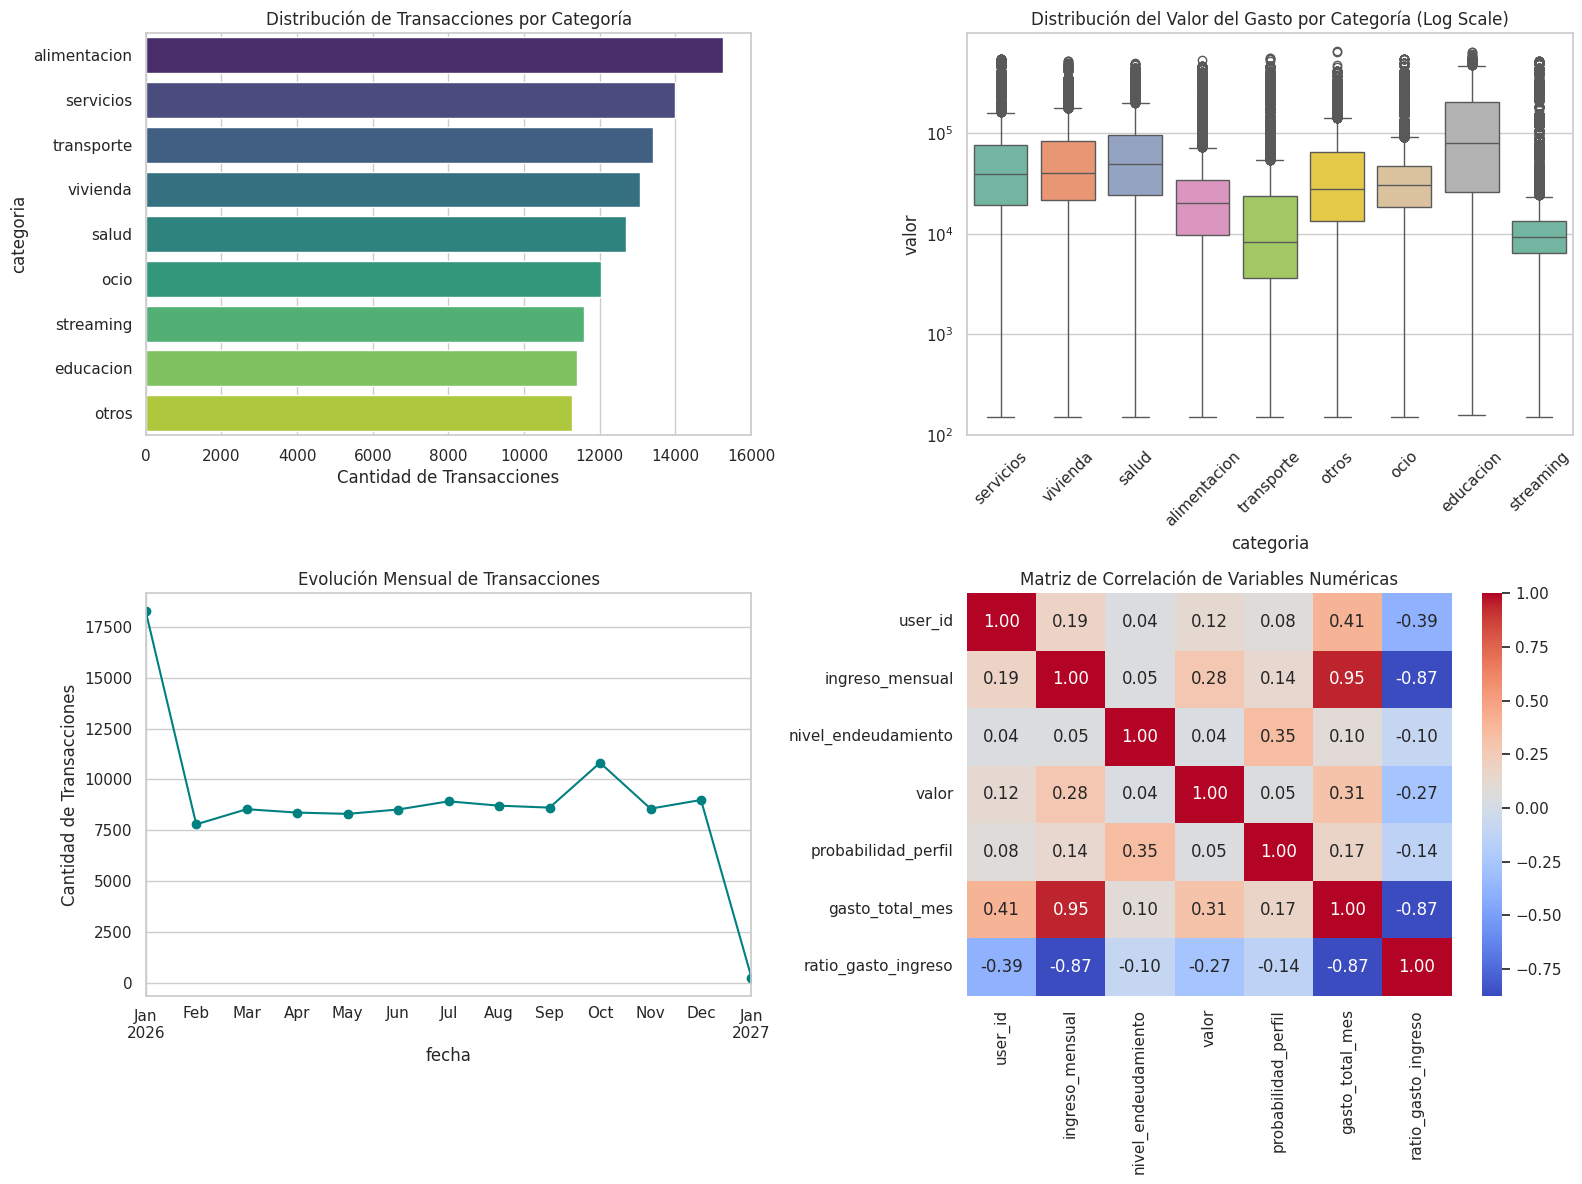

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# ==========================================
# 1. RESUMEN ESTRUCTURAL Y DE INTEGRIDAD
# ==========================================
print("=== 1. INFORMACIÓN GENERAL Y TIPOS DE DATOS ===")
print(df.info())

print("\n=== VALORES FALTANTES POR COLUMNA ===")
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df)) * 100
df_nulls = pd.DataFrame({"Nulos": nulls, "% Nulos": nulls_pct})
print(df_nulls[df_nulls["Nulos"] > 0])

print("\n=== DUPLICADOS REGISTRADOS ===")
print(f"Filas exactamente duplicadas: {df.duplicated().sum()}")

# ==========================================
# 2. ESTADÍSTICA DESCRIPTIVA NUMÉRICA
# ==========================================
print("\n=== 2. ESTADÍSTICA DESCRIPTIVA (VARIABLES NUMÉRICAS) ===")
cols_num = ["valor", "ingreso_mensual", "nivel_endeudamiento"]
print(df[cols_num].describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]])

# Medidas de forma
print("\n=== ASIMETRÍA (SKEWNESS) Y CURTOSIS ===")
for col in cols_num:
    print(
        f"{col} -> Asimetría: {df[col].skew():.2f} | Curtosis: {df[col].kurt():.2f}"
    )

# ==========================================
# 3. ANÁLISIS DE VARIABLES CATEGÓRICAS
# ==========================================
print("\n=== 3. DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS ===")
for col in ["categoria", "pais", "moneda", "frecuencia_ahorro", "tipo_texto", "origen_dataset"]:
    print(f"\n--- Columna: {col} ---")
    val_counts = df[col].value_counts(dropna=False)
    pcts = df[col].value_counts(normalize=True, dropna=False) * 100
    print(pd.DataFrame({"Conteo": val_counts, "Porcentaje (%)": pcts}))

# ==========================================
# 4. DETECCIÓN DE ANOMALÍAS Y OUTLIERS
# ==========================================
# Identificación de valores atípicos mediante IQR en el monto (valor)
Q1 = df["valor"].quantile(0.25)
Q3 = df["valor"].quantile(0.75)
IQR = Q3 - Q1
lim_inferior = Q1 - 1.5 * IQR
lim_superior = Q3 + 1.5 * IQR

outliers = df[(df["valor"] < lim_inferior) | (df["valor"] > lim_superior)]
print(
    f"\nOutliers detectados en 'valor' (Método IQR): {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)"
)

# ==========================================
# 5. VISUALIZACIONES PRINCIPALES
# ==========================================
# Convertimos la columna a fecha
df["fecha"] = pd.to_datetime(df["fecha"])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 5.1 Distribución de Categorías de Gasto
sns.barplot(
    y=df["categoria"].value_counts().index,
    x=df["categoria"].value_counts().values,
    ax=axes[0, 0],
    palette="viridis",
    hue=df["categoria"].value_counts().index,
    legend=False,
)
axes[0, 0].set_title("Distribución de Transacciones por Categoría")
axes[0, 0].set_xlabel("Cantidad de Transacciones")

# 5.2 Boxplot de Montos por Categoría (Escala Logarítmica para manejar dispersión)
sns.boxplot(
    data=df, x="categoria", y="valor", ax=axes[0, 1], palette="Set2", hue="categoria", legend=False,
)
axes[0, 1].set_yscale("log")
axes[0, 1].set_title("Distribución del Valor del Gasto por Categoría (Log Scale)")
axes[0, 1].tick_params(axis="x", rotation=45)

# 5.3 Evolución Temporal de Transacciones por Mes
df_mes = df.groupby(df["fecha"].dt.to_period("M")).size()
df_mes.plot(kind="line", marker="o", ax=axes[1, 0], color="teal")
axes[1, 0].set_title("Evolución Mensual de Transacciones")
axes[1, 0].set_ylabel("Cantidad de Transacciones")

# 5.4 Matriz de Correlación
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(
    numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1, 1]
)
axes[1, 1].set_title("Matriz de Correlación de Variables Numéricas")

plt.tight_layout()
plt.show()

**Resumen Ejecutivo del Análisis Exploratorio de Datos (EDA)**

---

#### **1. Diagnóstico de Calidad, Integridad y Estructura de Datos**

* **Muestra total y granularidad:** Se analizaron **68,177 registros** correspondientes a **440 usuarios únicos**. La arquitectura de datos combina transacciones en pesos argentinos (`ARS`) y pesos chilenos (`CLP`).
* **Integridad y datos faltantes:**
* Se observa un **29.33% de valores nulos** en las columnas procedentes de la fuente `new_data` (`comercio`, `perfil_financiero`, `probabilidad_perfil`, `recomendaciones`, `gasto_total_mes`, `ratio_gasto_ingreso`). Esto es estructural y esperado debido a la fusión de conjuntos de datos con esquemas asimétricos.


* **Duplicidad de registros:**
* Se identificaron **22,232 filas duplicadas** (32.6% del total). Es fundamental evaluar antes de la fase de modelado si estas repeticiones obedecen a transacciones recurrentes idénticas (p. ej., suscripciones/servicios) o a un sesgo de duplicación en la recolección, para prevenir el sobreajuste (*overfitting*) o fugas de información (*data leakage*) entre entrenamiento y prueba.



---

#### **2. Comportamiento Estadístico y Outliers en Variables Numéricas**

* **Variable dependiente / objetivo de gasto (`valor`):**
* Presenta una **asimetría positiva pronunciada (Skewness = 2.85)** y una **curtosis alta (9.63)**, con una mediana de **25,319** frente a una media de **50,754.16**.
* La presencia de dispersión extrema (mínimo de 150 y máximo de 655,697) justifica plenamente el uso de **transformaciones logarítmicas ($\log(1+x)$)** o escaladores robustos (*RobustScaler*) para estabilizar la varianza antes de alimentar modelos basados en distancia o regresión.


* **Ingresos y nivel de endeudamiento:**
* El `ingreso_mensual` presenta una distribución bimodal o ajustada por moneda (ARS/CLP) con una media de **716,403.61**.
* El `nivel_endeudamiento` muestra una **distribución uniforme** entre el 5% y el 80% (Media = 44.09, Asimetría = -0.06), lo que indica una muestra heterogénea de perfiles crediticios.



---

#### **3. Balance de Clases y Patrones Categóricos**

* **Distribución de categorías:** La variable objetivo para clasificación (`categoria`) se encuentra **altamente balanceada** a lo largo de sus 9 clases:
* *Alimentación* (14.09%) y *Servicios* (13.22%) lideran el volumen.
* *Educación* (9.21%) y *Otros* (8.98%) representan las frecuencias menores.
* Este equilibrio descarta la necesidad de aplicar técnicas agresivas de rebalanceo de clases (como SMOTE o undersampling).


* **Distribución geográfica:** Muestra una partición equitativa entre Argentina (**AR: 50.51%**) y Chile (**CL: 49.49%**).

---

#### **4. Implicaciones Directas para la Fase de ML y Feature Engineering**

1. **Preprocesamiento NLP:** Dado que las descripciones abarcan formatos sintéticos y de cartola bancaria (`tipo_texto`), el preprocesamiento de texto debe priorizar la remoción de stopwords financieras y la estandarización de patrones alfanuméricos mediante vectorizadores TF-IDF o Embeddings preentrenados.
2. **Normalización por Moneda:** Se sugiere escalar la variable `valor` de forma independiente por `pais`/`moneda` antes de incluirla como *feature* numérica pura, o basar el aprendizaje predominantemente en la semántica del texto (`descripcion`).
3. **Estrategia de Validación:** Se debe implementar un **GroupKFold** utilizando la columna `user_id` para garantizar que los datos de un mismo usuario no se dividan entre los conjuntos de entrenamiento y validación, evaluando la capacidad real de generalización del modelo.

### **Fase 3: Ingeniería de Atributos (Fechas y Texto)**

Aquí aplicamos limpieza de texto (quitando caracteres raros y stopwords). Además, incorporamos "Ruido Financiero"

In [ ]:
# ==========================================
# FASE 3: PREPROCESAMIENTO Y FECHAS
# ==========================================

import re
import unicodedata
import pandas as pd
import nltk
from nltk.corpus import stopwords

# 1. Preparación de Stopwords (Palabras vacías)
# Descargamos las palabras comunes del español (el, la, de, para, etc.)
nltk.download('stopwords')
stopwords_spanish = set(stopwords.words('spanish'))

# Definimos nuestro propio diccionario de "Ruido Financiero"
# Estas son palabras que no aportan a la categoría real del gasto
ruido_financiero = {
    # Verbos y términos transaccionales
    'transferencia', 'pago', 'compra', 'gasto', 'cajero', 'atm', 'pos', 'trx', 'suc', 'sucursal',
    # Billeteras, bancos y tarjetas (Argentina y Chile)
    'mercado', 'uala', 'naranja', 'modo', 'macro', 'brubank', 'dni', 'prex',
    'webpay', 'transbank', 'mach', 'tenpo', 'cuentarut', 'fpay', 'servipag', 'chek',
    'visa', 'mastercard', 'cabal', 'banelco', 'link', 'master'
}

# Unimos las reglas del idioma con nuestras reglas financieras en una sola lista maestra
stopwords_totales = stopwords_spanish.union(ruido_financiero)


# 2. Extracción de características de la fecha
# Convertimos la columna de texto a un formato de Fecha (DateTime) que Python entiende
df['fecha'] = pd.to_datetime(df['fecha'])

# Extraemos el día de la semana (Lunes = 0, Domingo = 6)
df['dia_semana'] = df['fecha'].dt.dayofweek
# Extraemos el mes (1 al 12)
df['mes'] = df['fecha'].dt.month
# Extraemos el día del mes (1 al 31)
df['dia'] = df['fecha'].dt.day


# 3. Función maestra de limpieza de texto
def limpiar_texto(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8")

    text = re.sub(r"\d+", "", text)
    texto_letras = re.sub(r"[^a-z\s]", "", text) # Guardamos esta versión intermedia

    palabras = [word for word in texto_letras.split() if word not in stopwords_totales]
    texto_final = " ".join(palabras)

    # Si las stopwords borraron todo y el texto quedó vacío,
    # devolvemos el texto original (sin números ni símbolos) para no dejar ciego al modelo.
    if texto_final.strip() == "" and texto_letras.strip() != "":
        return texto_letras.strip()

    return texto_final


# 4. Aplicar la limpieza al dataset
# Creamos una columna nueva llamada 'descripcion_clean' aplicando nuestra función a cada fila
df['descripcion_clean'] = df['descripcion'].apply(limpiar_texto)

print("Fechas procesadas y texto limpio (sin stopwords ni ruido financiero).")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Fechas procesadas y texto limpio (sin stopwords ni ruido financiero).


### **Fase 4: Prevención de Fugas (Separación por Usuario)**

Separar por user_id asegura que el modelo no haga trampa. Además, convertimos las categorías a números para que XGBoost no arroje errores.

In [ ]:
# ==========================================
# FASE 4: DIVISIÓN DE DATOS (TRAIN/TEST)
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Codificar el Target (XGBoost necesita que las clases sean 0, 1, 2...)
label_encoder = LabelEncoder()
df['categoria_encoded'] = label_encoder.fit_transform(df['categoria'])

# 2. Definir Features (X) y Target (y)
columnas_usar = ['descripcion_clean', 'valor', 'pais', 'tipo_texto', 'dia_semana', 'mes', 'dia', 'user_id']
X = df[columnas_usar]
y = df['categoria_encoded']

# 3. Separación estricta por usuarios (80% Train, 20% Test)
usuarios_unicos = df['user_id'].unique()
train_users, test_users = train_test_split(usuarios_unicos, test_size=0.2, random_state=42)

# Crear máscaras
train_mask = df['user_id'].isin(train_users)
test_mask = df['user_id'].isin(test_users)

# Aplicar máscaras
X_train = X[train_mask].drop(columns=['user_id']) # Quitamos user_id porque el modelo no debe aprenderlo
X_test = X[test_mask].drop(columns=['user_id'])
y_train = y[train_mask]
y_test = y[test_mask]

print(f"Train: {X_train.shape[0]} filas. Test: {X_test.shape[0]} filas.")

Train: 92847 filas. Test: 21843 filas.


### **Fase 5: El Pipeline y ColumnTransformer**

Aquí está el núcleo de la fusión. Usamos tu ColumnTransformer pero le inyectamos la configuración de CountVectorizer.

In [ ]:
# ==========================================
# FASE 5: ARQUITECTURA DEL MODELO
# ==========================================

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

procesador = ColumnTransformer(
    transformers=[
        # ¡Cambiamos min_df a 1 para que no borre palabras únicas como "tello" o "netflix"!
        ('texto', CountVectorizer(ngram_range=(1,2), min_df=1), 'descripcion_clean'),

        ('numeros', StandardScaler(), ['valor', 'mes', 'dia']),
        ('categorias', OneHotEncoder(handle_unknown='ignore'), ['pais', 'tipo_texto', 'dia_semana'])
    ]
)

print("ColumnTransformer listo para ensamblar (sin filtro de palabras raras).")

ColumnTransformer listo para ensamblar (sin filtro de palabras raras).


### **Fase 6: Entrenamiento de los 3 Modelos (con Balanceo de clases)**


Entrenando Logistic Regression...
Exactitud (Accuracy): 0.9692
Tiempo de procesamiento: 11.87 segundos

Reporte detallado de Logistic Regression:
              precision    recall  f1-score   support

alimentacion       0.84      1.00      0.91      2863
   educacion       0.99      0.97      0.98      2155
        ocio       1.00      0.95      0.98      2189
       otros       1.00      0.94      0.97      2291
       salud       0.99      0.96      0.97      2240
   servicios       1.00      0.97      0.98      2670
   streaming       0.98      0.99      0.98      2303
  transporte       1.00      0.97      0.98      2581
    vivienda       1.00      0.97      0.98      2551

    accuracy                           0.97     21843
   macro avg       0.98      0.97      0.97     21843
weighted avg       0.97      0.97      0.97     21843



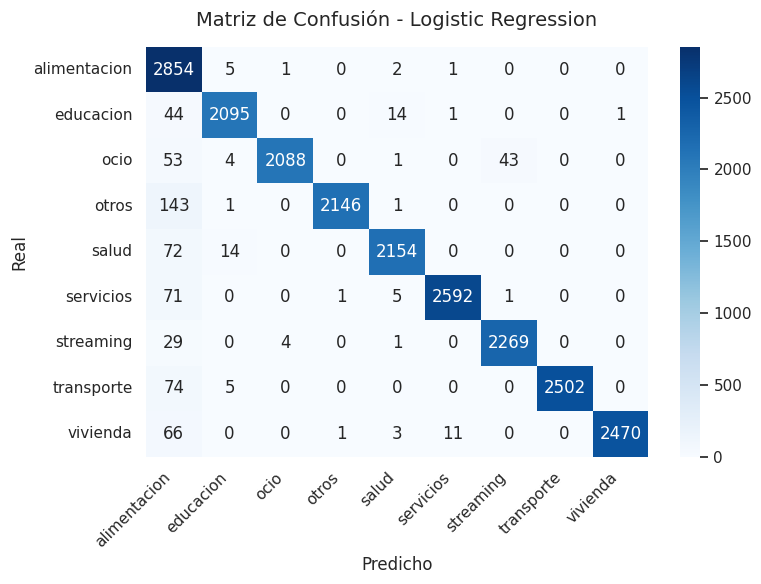


Entrenando LinearSVC...


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Exactitud (Accuracy): 0.9702
Tiempo de procesamiento: 53.99 segundos

Reporte detallado de LinearSVC:
              precision    recall  f1-score   support

alimentacion       0.83      1.00      0.91      2863
   educacion       1.00      0.97      0.98      2155
        ocio       1.00      0.97      0.98      2189
       otros       1.00      0.94      0.97      2291
       salud       1.00      0.96      0.98      2240
   servicios       1.00      0.97      0.98      2670
   streaming       0.98      0.99      0.98      2303
  transporte       1.00      0.97      0.99      2581
    vivienda       1.00      0.97      0.98      2551

    accuracy                           0.97     21843
   macro avg       0.98      0.97      0.97     21843
weighted avg       0.97      0.97      0.97     21843



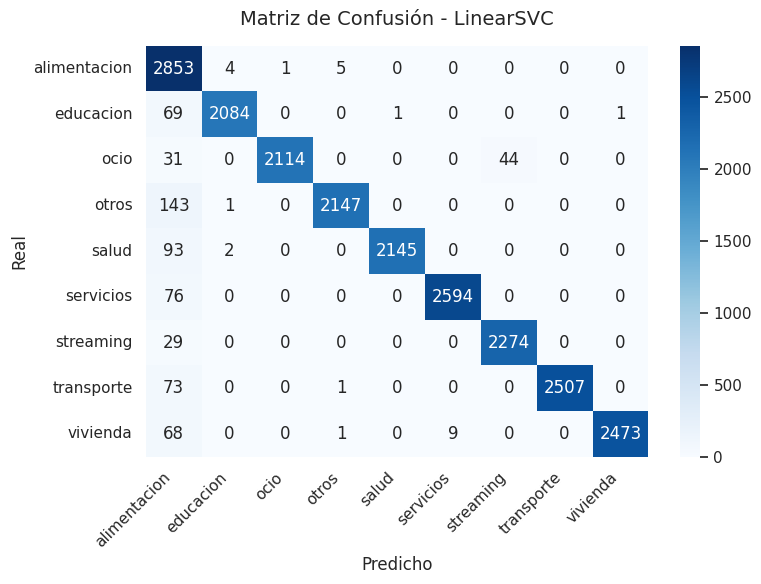


Entrenando XGBoost...
Exactitud (Accuracy): 0.9222
Tiempo de procesamiento: 18.78 segundos

Reporte detallado de XGBoost:
              precision    recall  f1-score   support

alimentacion       0.73      0.97      0.83      2863
   educacion       0.98      0.93      0.96      2155
        ocio       1.00      0.89      0.94      2189
       otros       0.96      0.89      0.92      2291
       salud       0.89      0.90      0.90      2240
   servicios       0.97      0.91      0.94      2670
   streaming       0.97      0.97      0.97      2303
  transporte       0.95      0.93      0.94      2581
    vivienda       1.00      0.89      0.94      2551

    accuracy                           0.92     21843
   macro avg       0.94      0.92      0.93     21843
weighted avg       0.93      0.92      0.92     21843



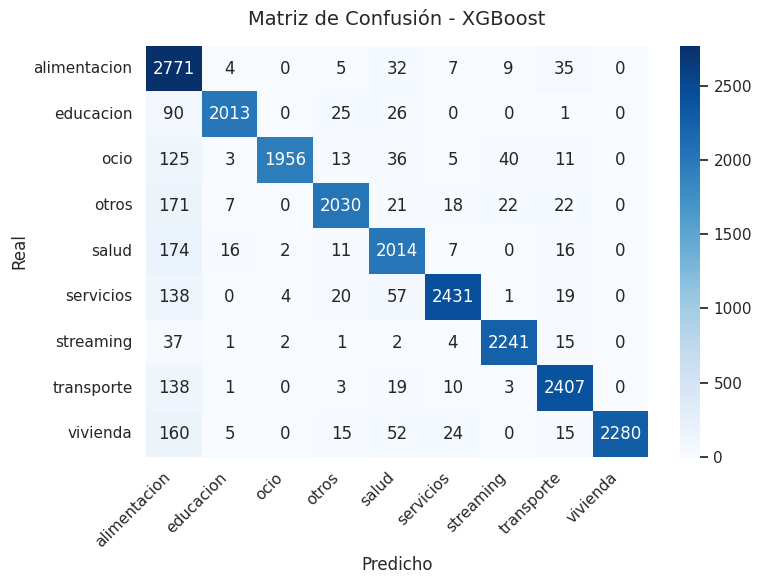

In [ ]:
# ==========================================
# FASE 6: ENTRENAMIENTO Y EVALUACIÓN
# ==========================================
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
import seaborn as sns
import time

# 1. Definir los 3 modelos a competir
# ¡Agregamos max_iter=3000 en LinearSVC para quitar la advertencia!
modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    "LinearSVC": LinearSVC(C=2, loss="hinge", random_state=42, class_weight='balanced', max_iter=3000),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
}

# 2. Calculamos los pesos dinámicos exclusivamente para XGBoost
pesos_xgb = compute_sample_weight(class_weight='balanced', y=y_train)

# 3. Entrenar y evaluar en un bucle
for nombre, algoritmo in modelos.items():
    print("\n" + "="*60)
    print(f"Entrenando {nombre}...")
    print("="*60)

    # Armamos el pipeline uniendo el preprocesador con el algoritmo
    pipeline = Pipeline(steps=[
        ('preprocesador', procesador),
        ('clasificador', algoritmo)
    ])

    # Medimos el tiempo
    inicio = time.time()

    # Inyectamos los pesos según el modelo
    if nombre == "XGBoost":
        pipeline.fit(X_train, y_train, clasificador__sample_weight=pesos_xgb)
    else:
        pipeline.fit(X_train, y_train)

    # Predecir
    y_pred = pipeline.predict(X_test)

    fin = time.time()

    # Resultados Generales
    acc = accuracy_score(y_test, y_pred)
    print(f"Exactitud (Accuracy): {acc:.4f}")
    print(f"Tiempo de procesamiento: {fin - inicio:.2f} segundos\n")

    # 3. Reporte de Clasificación Detallado
    print(f"Reporte detallado de {nombre}:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    # 4. Generar y dibujar la Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)

    plt.title(f'Matriz de Confusión - {nombre}', fontsize=14, pad=15)
    plt.xlabel('Predicho', fontsize=12)
    plt.ylabel('Real', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    # Ajustar diseño y mostrar
    plt.tight_layout()
    plt.show()

### **Fase 7: Archivo PKL y ejemplos para su uso**

#### 💾 1. Código para entrenar el modelo final y generar el .pkl

In [ ]:
# ==========================================
# FASE 7: Archivo PKL y ejemplos para su uso
# ==========================================
import joblib
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# 1. Definimos el pipeline definitivo con el GANADOR (con pesos balanceados)
pipeline_final = Pipeline(steps=[
    ('preprocesador', procesador), # El ColumnTransformer que ya tenías
    ('clasificador', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')) # ¡Faltaba el balanceo aquí!
])

print("Entrenando el modelo final balanceado...")
pipeline_final.fit(X_train, y_train)

# 2. Guardamos el pipeline completo en un archivo .pkl
nombre_archivo = 'modelo_finanzas_v4.pkl'
joblib.dump(pipeline_final, nombre_archivo)

print(f"¡Éxito! Modelo guardado como: {nombre_archivo}")

Entrenando el modelo final balanceado...
¡Éxito! Modelo guardado como: modelo_finanzas_v4.pkl


#### 🧪 2. Prueba de modelo "modelo_finanzas_v4.pkl"  (5 ejemplos)

In [ ]:
import joblib
import pandas as pd
import numpy as np

# 1. Cargamos el modelo (el Backend usará esta misma línea de código)
modelo_cargado = joblib.load('modelo_finanzas_v4.pkl')

# 2. Creamos 5 transacciones de prueba simulando la entrada de la API
# Nota: La descripción ya debe venir limpia o pasar por tu función limpiar_texto() antes
datos_prueba = pd.DataFrame({
    'descripcion_clean': [
        'compra de medicamentos en farmacity',           # Salud
        'suscripcion mensual netflix argentina',         # Streaming
        'pasaje transporte urbano palpala',              # Transporte
        'pago cuota mensual instituto eugenio tello',    # Educacion
        'compra de mercaderia en despensa el milagro'    # Alimentacion,
     ],
    'valor': [15000, 4500, 3200, 25000, 68000],
    'pais': ['AR', 'AR', 'AR', 'AR', 'AR'],
    'tipo_texto': ['natural', 'cartola', 'natural', 'natural', 'cartola'],
    'dia_semana': [2, 4, 5, 1, 6], # Simulamos días al azar (0=Lunes, 6=Domingo)
    'mes': [8, 8, 8, 8, 8],
    'dia': [12, 15, 20, 5, 28]
})

# 3. Realizamos las predicciones y extraemos las probabilidades
# predict() nos da el número de la categoría
predicciones_num = modelo_cargado.predict(datos_prueba)

# predict_proba() nos da los porcentajes de confianza para armar el JSON del desafío
probabilidades = modelo_cargado.predict_proba(datos_prueba)

# 4. Mostramos los resultados finales traduciendo el número a la etiqueta real
print("\n--- RESULTADOS DE LAS PREDICCIONES ---")
for i in range(len(datos_prueba)):
    descripcion = datos_prueba['descripcion_clean'].iloc[i]

    # Usamos tu label_encoder original para traducir el [0, 1, 2...] a "salud", "transporte", etc.
    categoria_texto = label_encoder.inverse_transform([predicciones_num[i]])[0]

    # Extraemos la probabilidad más alta de esa predicción
    probabilidad_max = np.max(probabilidades[i]) * 100

    print(f"Transacción: '{descripcion}'")
    print(f" -> Categoría: {categoria_texto.upper()} (Confianza: {probabilidad_max:.2f}%)\n")


--- RESULTADOS DE LAS PREDICCIONES ---
Transacción: 'compra de medicamentos en farmacity'
 -> Categoría: SALUD (Confianza: 81.82%)

Transacción: 'suscripcion mensual netflix argentina'
 -> Categoría: STREAMING (Confianza: 99.62%)

Transacción: 'pasaje transporte urbano palpala'
 -> Categoría: TRANSPORTE (Confianza: 90.67%)

Transacción: 'pago cuota mensual instituto eugenio tello'
 -> Categoría: EDUCACION (Confianza: 93.68%)

Transacción: 'compra de mercaderia en despensa el milagro'
 -> Categoría: ALIMENTACION (Confianza: 36.25%)



#### 🧪 2.1 Segunda prueba del modelo (5 ejemplos)

In [ ]:
import joblib
import pandas as pd
import numpy as np

# 1. Cargamos el modelo (el Backend usará esta misma línea de código)
modelo_cargado = joblib.load('modelo_finanzas_v4.pkl')

# 2. Creamos 5 transacciones de prueba simulando la entrada de la API
# Nota: La descripción ya debe venir limpia o pasar por tu función limpiar_texto() antes
datos_prueba = pd.DataFrame({
    'descripcion_clean': [
        'compra de medicamentos en farmacity',           # Salud
        'suscripcion mensual netflix argentina',         # Streaming
        'pasaje transporte urbano palpala',              # Transporte
        'pago cuota mensual instituto eugenio tello',    # Educacion
        'compra de mercaderia en despensa el milagro'    # Alimentacion,
     ],
    'valor': [15000, 4500, 3200, 25000, 68000],
    'pais': ['AR', 'AR', 'AR', 'AR', 'AR'],
    'tipo_texto': ['natural', 'cartola', 'natural', 'natural', 'cartola'],
    'dia_semana': [2, 4, 5, 1, 6], # Simulamos días al azar (0=Lunes, 6=Domingo)
    'mes': [8, 8, 8, 8, 8],
    'dia': [12, 15, 20, 5, 28]
})

# 3. Realizamos las predicciones y extraemos las probabilidades
# predict() nos da el número de la categoría
predicciones_num = modelo_cargado.predict(datos_prueba)

# predict_proba() nos da los porcentajes de confianza para armar el JSON del desafío
probabilidades = modelo_cargado.predict_proba(datos_prueba)

# 4. Mostramos los resultados finales traduciendo el número a la etiqueta real
print("\n--- RESULTADOS DE LAS PREDICCIONES ---")
for i in range(len(datos_prueba)):
    descripcion = datos_prueba['descripcion_clean'].iloc[i]

    # Usamos tu label_encoder original para traducir el [0, 1, 2...] a "salud", "transporte", etc.
    categoria_texto = label_encoder.inverse_transform([predicciones_num[i]])[0]

    # Extraemos la probabilidad más alta de esa predicción
    probabilidad_max = np.max(probabilidades[i]) * 100

    print(f"Transacción: '{descripcion}'")
    print(f" -> Categoría: {categoria_texto.upper()} (Confianza: {probabilidad_max:.2f}%)\n")


--- RESULTADOS DE LAS PREDICCIONES ---
Transacción: 'compra de medicamentos en farmacity'
 -> Categoría: SALUD (Confianza: 81.82%)

Transacción: 'suscripcion mensual netflix argentina'
 -> Categoría: STREAMING (Confianza: 99.62%)

Transacción: 'pasaje transporte urbano palpala'
 -> Categoría: TRANSPORTE (Confianza: 90.67%)

Transacción: 'pago cuota mensual instituto eugenio tello'
 -> Categoría: EDUCACION (Confianza: 93.68%)

Transacción: 'compra de mercaderia en despensa el milagro'
 -> Categoría: ALIMENTACION (Confianza: 36.25%)

